In [1]:
import pandas as pd
import numpy as np
import sklearn

print("Libraries working!")

Libraries working!


In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from data_preprocessing import preprocess_pipeline

In [3]:
data_path = "../data/raw/customer_dataset.csv"

result = preprocess_pipeline(data_path)

print(type(result))
print(result)


<class 'pandas.DataFrame'>
            Age    Gender  Education Level  Geographic Information  \
0     -1.401980 -1.028344        -1.365141                0.547943   
1     -1.203033  0.972437         0.057168               -0.637324   
2     -1.004085 -1.028344        -1.365141                1.041804   
3     -1.600928  0.972437        -0.653987                1.140576   
4     -1.269349 -1.028344        -0.653987                1.733210   
...         ...       ...              ...                     ...   
53498 -0.606190 -1.028344        -1.365141               -1.625046   
53499  1.118023  0.972437         0.057168               -0.341007   
53500 -1.269349  0.972437         0.057168               -1.328729   
53501 -0.141979  0.972437         0.057168               -1.526274   
53502 -1.600928  0.972437         0.057168               -0.834868   

       Occupation  Income Level  Interactions with Customer Service  \
0       -0.420389     -0.333617                            1.

In [4]:
data_path = "../data/raw/customer_dataset.csv"

X = preprocess_pipeline(data_path)

X.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028


In [5]:
import pandas as pd

X.to_csv("../data/processed/processed_customer_data.csv", index=False)

In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 53503 non-null  float64
 1   Gender                              53503 non-null  float64
 2   Education Level                     53503 non-null  float64
 3   Geographic Information              53503 non-null  float64
 4   Occupation                          53503 non-null  float64
 5   Income Level                        53503 non-null  float64
 6   Interactions with Customer Service  53503 non-null  float64
 7   Insurance Products Owned            53503 non-null  float64
 8   Preferred Contact Time              53503 non-null  float64
 9   Preferred Language                  53503 non-null  float64
 10  Segmentation Group                  53503 non-null  float64
dtypes: float64(11)
memory usage: 4.5 MB


In [7]:
X.describe()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group
count,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04,5.350300e+04
mean,-9.163495e-17,1.274921e-16,6.401166e-17,-2.762329e-17,2.921694e-17,-7.755770e-17,3.691959e-17,6.905823e-18,4.834076e-17,7.437040e-17,-6.640214e-17
std,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00,1.000009e+00
min,-1.733560e+00,-1.028344e+00,-1.365141e+00,-1.625046e+00,-1.577748e+00,-1.712580e+00,-1.293483e+00,-1.241050e+00,-1.621059e+00,-1.419718e+00,-1.511559e+00
25%,-8.051374e-01,-1.028344e+00,-6.539865e-01,-8.348684e-01,-8.061756e-01,-8.512742e-01,-1.293483e+00,-5.520614e-01,-9.192794e-01,-6.471159e-01,-8.160275e-01
50%,-7.566279e-02,9.724373e-01,5.716833e-02,-4.469054e-02,-3.460343e-02,-5.591496e-02,7.818045e-02,1.369272e-01,4.842793e-01,1.254867e-01,-1.204957e-01
75%,8.527595e-01,9.724373e-01,7.683232e-01,8.442595e-01,1.122755e+00,9.059894e-01,7.640123e-01,8.259158e-01,1.186059e+00,8.980893e-01,1.270568e+00
max,1.714866e+00,9.724373e-01,1.479478e+00,1.733210e+00,1.508541e+00,1.834361e+00,1.449844e+00,1.514904e+00,1.186059e+00,1.670692e+00,1.270568e+00


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

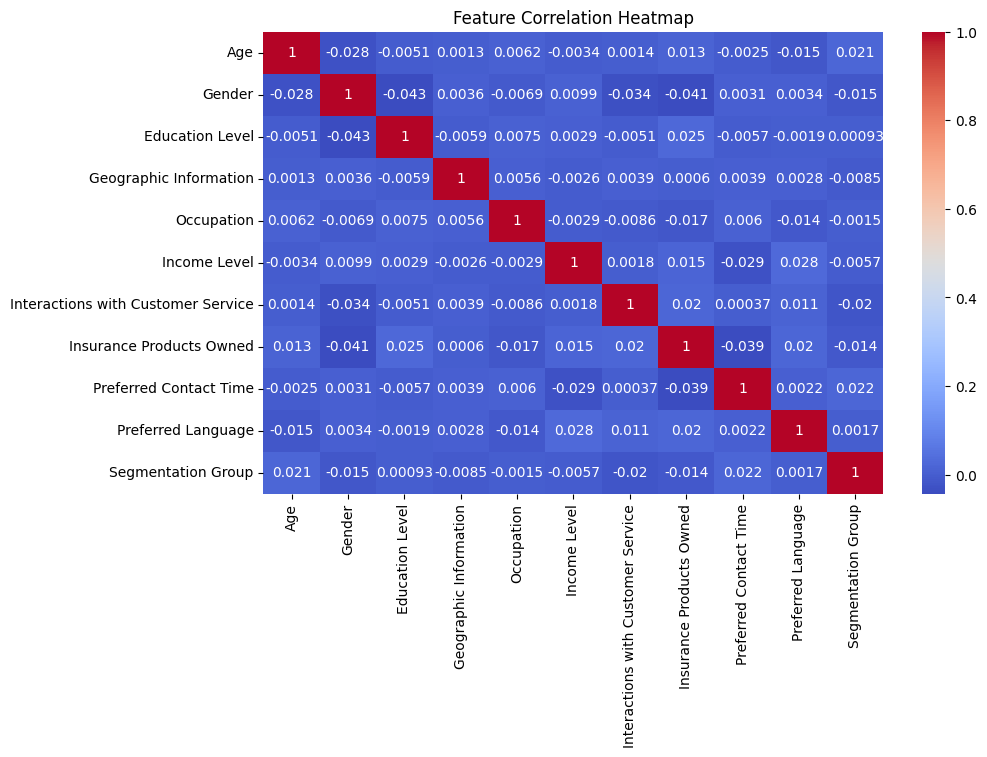

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

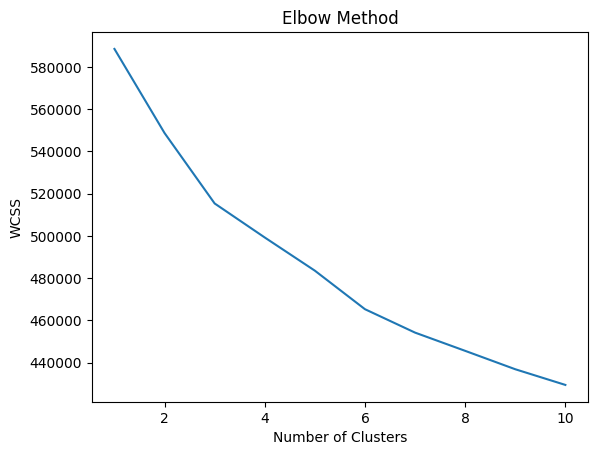

In [11]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

X["Cluster"] = clusters

X.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group,Cluster
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568,2
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568,1
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496,1
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496,1
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028,1


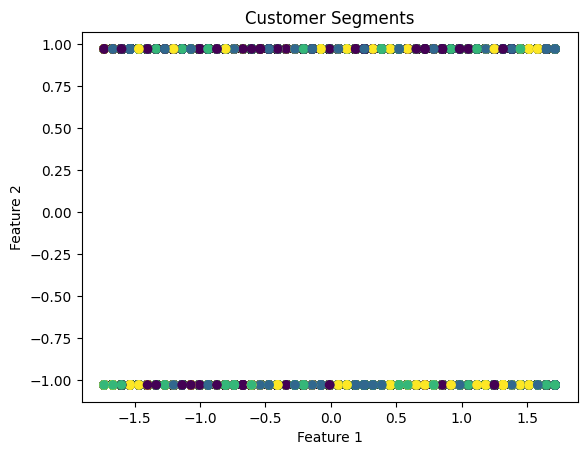

In [13]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=X["Cluster"], cmap="viridis")
plt.title("Customer Segments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

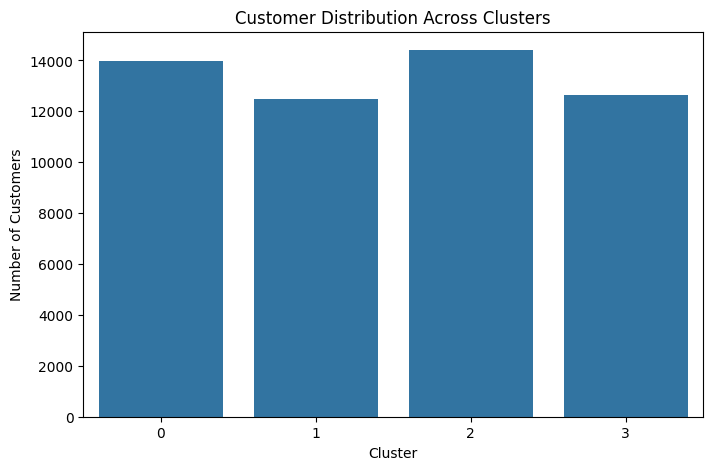

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="Cluster", data=X)
plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

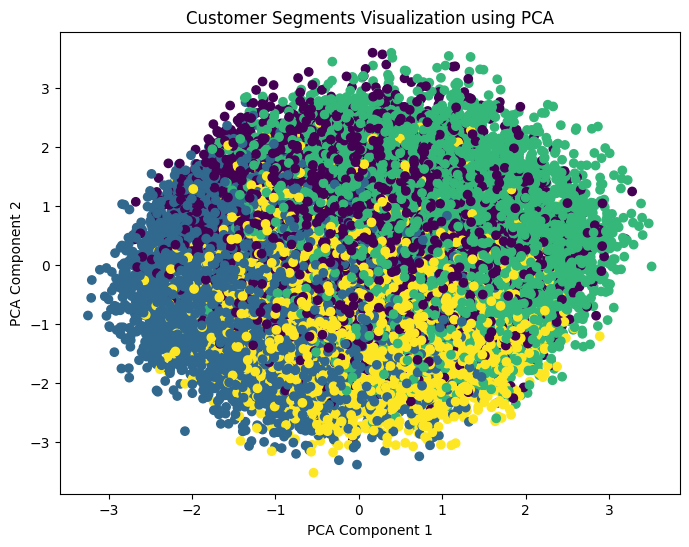

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=X["Cluster"], cmap="viridis")
plt.title("Customer Segments Visualization using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, X["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.058519015550278566


In [17]:
X.to_csv("../data/processed/customer_segments.csv", index=False)

In [ ]:
# imports
import pandas as pd
import numpy as np
from src.data_preprocessing import preprocess_pipeline

# load raw data
data_path = "../data/raw/customer_dataset.csv"
X = preprocess_pipeline(data_path)

# show first few rows
X.head()

# optionally save cleaned data
X.to_csv("../data/processed/processed_customer_data.csv", index=False)